In [1]:
!pip install -U datasets wandb
!pip install -U evaluate jiwer

  Obtaining dependency information for datasets from https://files.pythonhosted.org/packages/ec/93/454ada0d1b289a0f4a86ac88dbdeab54921becabac45da3da787d136628f/datasets-2.16.1-py3-none-any.whl.metadata
  Obtaining dependency information for pyarrow-hotfix from https://files.pythonhosted.org/packages/e4/f4/9ec2222f5f5f8ea04f66f184caafd991a39c8782e31f5b0266f101cb68ca/pyarrow_hotfix-0.6-py3-none-any.whl.metadata
  Obtaining dependency information for fsspec[http]<=2023.10.0,>=2023.1.0 from https://files.pythonhosted.org/packages/e8/f6/3eccfb530aac90ad1301c582da228e4763f19e719ac8200752a4841b0b2d/fsspec-2023.10.0-py3-none-any.whl.metadata
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.1/507.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.4/166.4 kB 16.5 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2023.12.2
    Uninstalling fsspec-2023.12.2:
      Successfully uninstalled fsspec-2023.12.2
  Attempting uninstall: datasets

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


In [3]:
import os
os.environ["WANDB_PROJECT"]="Upwork-speech assessment"

# save your trained model checkpoint to wandb
os.environ["WANDB_LOG_MODEL"]="true"

# turn off watch to log faster
os.environ["WANDB_WATCH"]="false"

In [4]:
from datasets import load_dataset

In [5]:
def clear_phonemes(features):
    def clear_punc(text):
        text      = text.split()
        new_words = []
        for word in text:
            new_phonems = []
            phonemes = word.split('-')
            for ph in phonemes:
                if ph in ('', '!', ',', '?', "'"):
                    continue
                elif ph[-1].isdigit():
                    new_phonems.append(ph[:-1])
                    continue
                new_phonems.append(ph)
            new_words.append(new_phonems)
        return new_words
    features['phonetic'] = clear_punc(features['phonetic'])
    return features

In [8]:
l1_hind_kids_phoneme = load_dataset('mirfan899/kids_phoneme_asr')
l1_hind_kids_phoneme = l1_hind_kids_phoneme['train']
l1_hind_kids_phoneme = l1_hind_kids_phoneme.map(clear_phonemes)
l1_hind_kids_phoneme = l1_hind_kids_phoneme.train_test_split(train_size=0.90)

In [9]:
l1_us_phoneme = load_dataset('mirfan899/phoneme_asr')
l1_us_phoneme = l1_us_phoneme['train']
l1_us_phoneme = l1_us_phoneme.map(clear_phonemes)
l1_us_phoneme = l1_us_phoneme.train_test_split(train_size=0.90)

In [10]:
l1_hind_kids_phoneme['train']['phonetic'][0]

[['N', 'EY', 'CH', 'ER'],
 ['IH', 'Z'],
 ['AE', 'Z'],
 ['K', 'EH', 'R', 'IH', 'NG'],
 ['AE', 'Z'],
 ['AW', 'ER'],
 ['M', 'AH', 'DH', 'ER'],
 ['IH', 'T', 'S'],
 ['AO', 'L', 'W', 'EY', 'Z'],
 ['S', 'W', 'IY', 'T'],
 ['L', 'AY', 'K'],
 ['HH', 'ER']]

In [11]:
l1_us_phoneme['train']['phonetic'][3]

[['AH', 'L', 'AW'],
 ['L', 'IY', 'W', 'EY'],
 ['HH', 'IY', 'R'],
 ['B', 'AH', 'T'],
 ['R', 'AE', 'SH', 'AH', 'N', 'AH', 'L', 'AY', 'Z'],
 ['AO', 'L'],
 ['EH', 'R', 'ER', 'Z']]

In [14]:
h1ph_dict = []
for s in ['train', 'test']:
    for row in l1_hind_kids_phoneme[s]:
        phones = row['phonetic']
        phones = [ph for wph in phones for ph in wph]
        h1ph_dict.extend(phones)
h1ph_dict = set(h1ph_dict)

In [15]:
ph_dict = []
for s in ['train', 'test']:
    for row in l1_us_phoneme[s]:
        phones = row['phonetic']
        phones = [ph for wph in phones for ph in wph]
        ph_dict.extend(phones)
ph_dict = set(h1ph_dict)

In [16]:
phoneme_set = list(ph_dict.union(h1ph_dict)) + [' ']
phoneme_set.sort()
vocab_dict = {v: k for k, v in enumerate(phoneme_set)}
vocab_dict["|"] = vocab_dict[" "]
del vocab_dict[" "]

vocab_dict["[silence]"] = len(vocab_dict)
vocab_dict["[PAD]"] = len(vocab_dict)
vocab_dict["[UNK]"] = len(vocab_dict)

len(vocab_dict)

43

In [17]:
import json
with open('/kaggle/working/vocab.json', 'w') as vocab_file:
    json.dump(vocab_dict, vocab_file)

In [18]:
def merge_phonemes(features):
    one_phone_lits = []
    for word in features['phonetic']:
        one_phone_lits.extend(word)
        one_phone_lits.append('[silence]')
    one_phone_lits.pop()
    features['phonetic'] = ' '.join(one_phone_lits)
    return features

In [19]:
l1_us_phoneme = l1_us_phoneme.map(merge_phonemes)
l1_hind_kids_phoneme = l1_hind_kids_phoneme.map(merge_phonemes)

Map:   0%|          | 0/3024 [00:00<?, ? examples/s]

Map:   0%|          | 0/336 [00:00<?, ? examples/s]

Map:   0%|          | 0/4478 [00:00<?, ? examples/s]

Map:   0%|          | 0/498 [00:00<?, ? examples/s]

In [20]:
l1_us_phoneme['train']['phonetic'][10]

'D OW N T [silence] AE S K [silence] M IY [silence] T UW [silence] K AE R IY [silence] AE N [silence] OY L IY [silence] R AE G [silence] L AY K [silence] DH AE T'

In [21]:
from datasets import concatenate_datasets 

In [22]:
train_dataset = concatenate_datasets((l1_us_phoneme['train'], l1_hind_kids_phoneme['train']), )
test_dataset = concatenate_datasets((l1_us_phoneme['test'], l1_hind_kids_phoneme['test']), )

In [23]:
train_dataset

Dataset({
    features: ['audio', 'text', 'phonetic'],
    num_rows: 7502
})

In [24]:
from transformers import Wav2Vec2ForCTC, Wav2Vec2FeatureExtractor, Wav2Vec2CTCTokenizer, Wav2Vec2Processor

In [25]:
tokenizer = Wav2Vec2CTCTokenizer.from_pretrained("/kaggle/working/", 
                                                 unk_token="[UNK]", 
                                                 pad_token="[PAD]",
                                                 word_delimiter_token="|", ) 

feature_extractor = Wav2Vec2FeatureExtractor.from_pretrained("facebook/wav2vec2-base-100k-voxpopuli")
processor = Wav2Vec2Processor(feature_extractor, tokenizer)
asr_model = Wav2Vec2ForCTC.from_pretrained("facebook/wav2vec2-base-100k-voxpopuli",
                                           vocab_size=processor.tokenizer.vocab_size,
                                           pad_token_id=processor.tokenizer.pad_token_id,
                                           ctc_loss_reduction='mean',
                                           ctc_zero_infinity=True,
                                           hidden_act='gelu_new',
                                           hidden_dropout=0.05,
                                           activation_dropout=0.006,
                                           attention_dropout=0.04,
                                           mask_time_prob=0.005,
                                           mask_time_length=5,
                                           mask_feature_prob=0.018,
                                           mask_feature_length=7,
                                           mask_feature_min_masks=2,
                                           final_dropout=0.07,
                                           layerdrop=0.05,
                                          )



Ignored unknown kwarg option normalize
Ignored unknown kwarg option normalize
Ignored unknown kwarg option normalize
Ignored unknown kwarg option normalize


preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.55k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/380M [00:00<?, ?B/s]

Some weights of Wav2Vec2ForCTC were not initialized from the model checkpoint at facebook/wav2vec2-base-100k-voxpopuli and are newly initialized: ['lm_head.bias', 'lm_head.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [26]:
asr_model.freeze_feature_encoder()
asr_model.freeze_base_model()
for p in asr_model.wav2vec2.encoder.layers[10:].parameters():
    p.requires_grad = True

In [27]:
x = 0
for p in asr_model.parameters():
    x += p.numel() if p.requires_grad else 0
x

14208811

In [28]:
def prepare_dataset(batch):
    audio = batch["audio"]
    
    # batched output is "un-batched"
    batch["input_values"] = processor(audio["array"], sampling_rate=audio["sampling_rate"]).input_values[0]
    batch["input_length"] = len(batch["input_values"])
    
    batch["labels"] = processor(text=batch["phonetic"]).input_ids
    return batch

In [29]:
train_dataset = train_dataset.filter(lambda example: len(example["audio"]['array']) < 304000,).shuffle(seed=77).map(prepare_dataset, num_proc=2)
test_dataset = test_dataset.filter(lambda example: len(example["audio"]['array']) < 304000,).shuffle(seed=77).map(prepare_dataset, num_proc=2)

Filter:   0%|          | 0/7502 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/7436 [00:00<?, ? examples/s]

/opt/conda/lib/python3.10/site-packages/transformers/models/wav2vec2/processing_wav2vec2.py:156: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/transformers/models/wav2vec2/processing_wav2vec2.py:156: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/transformers/models/wav2vec2/feature_extraction_wav2vec2.py:98: RuntimeWarning: Mean of empty slice.
  normed_input_values = [(x - x.mean()) / np.sqrt(x.var() + 1e-7) for x in input_values]
/opt/conda/lib/python3.10/site-package

Filter:   0%|          | 0/834 [00:00<?, ? examples/s]

Map (num_proc=2):   0%|          | 0/829 [00:00<?, ? examples/s]

/opt/conda/lib/python3.10/site-packages/transformers/models/wav2vec2/processing_wav2vec2.py:156: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(
/opt/conda/lib/python3.10/site-packages/transformers/models/wav2vec2/processing_wav2vec2.py:156: UserWarning: `as_target_processor` is deprecated and will be removed in v5 of Transformers. You can process your labels by using the argument `text` of the regular `__call__` method (either in the same call as your audio inputs, or in a separate call.
  warnings.warn(


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: ylabel='Count'>

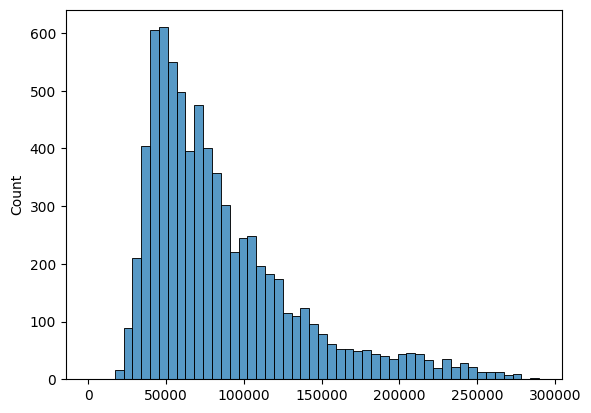

In [30]:
import seaborn as sns
sns.histplot(train_dataset['input_length'])


In [ ]:
# train_dataset = train_dataset.filter(lambda example: example["input_length"] < 304000,)

In [ ]:
# test_dataset = test_dataset.filter(lambda example: example["input_length"] < 304000)

In [31]:
train_dataset

Dataset({
    features: ['audio', 'text', 'phonetic', 'input_values', 'input_length', 'labels'],
    num_rows: 7436
})

In [32]:
test_dataset

Dataset({
    features: ['audio', 'text', 'phonetic', 'input_values', 'input_length', 'labels'],
    num_rows: 829
})

In [ ]:
300000 / 16000

In [ ]:
19*16000

In [33]:
processor.tokenizer

Wav2Vec2CTCTokenizer(name_or_path='/kaggle/working/', vocab_size=43, model_max_length=1000000000000000019884624838656, is_fast=False, padding_side='right', truncation_side='right', special_tokens={'bos_token': '<s>', 'eos_token': '</s>', 'unk_token': '[UNK]', 'pad_token': '[PAD]'}, clean_up_tokenization_spaces=True),  added_tokens_decoder={
	1: AddedToken("AA", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	2: AddedToken("AE", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	3: AddedToken("AH", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	4: AddedToken("AO", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	5: AddedToken("AW", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	6: AddedToken("AY", rstrip=True, lstrip=True, single_word=False, normalized=False, special=False),
	8: AddedToken("CH", rstrip=True, lstrip=True, single_wor

In [34]:
import torch
from transformers import PreTrainedTokenizerBase
from dataclasses import dataclass, field
from typing import Any, Dict, List, Optional, Union

@dataclass
class DataCollatorCTCWithPadding:
    """
    Data collator that will dynamically pad the inputs received.
    Args:
        processor (:class:`~transformers.Wav2Vec2Processor`)
            The processor used for proccessing the data.
        padding (:obj:`bool`, :obj:`str` or :class:`~transformers.tokenization_utils_base.PaddingStrategy`, `optional`, defaults to :obj:`True`):
            Select a strategy to pad the returned sequences (according to the model's padding side and padding index)
            among:
            * :obj:`True` or :obj:`'longest'`: Pad to the longest sequence in the batch (or no padding if only a single
              sequence if provided).
            * :obj:`'max_length'`: Pad to a maximum length specified with the argument :obj:`max_length` or to the
              maximum acceptable input length for the model if that argument is not provided.
            * :obj:`False` or :obj:`'do_not_pad'` (default): No padding (i.e., can output a batch with sequences of
              different lengths).
    """

    processor: PreTrainedTokenizerBase
    padding: Union[bool, str] = True

    def __call__(self, features: List[Dict[str, Union[List[int], torch.Tensor]]]) -> Dict[str, torch.Tensor]:
        # split inputs and labels since they have to be of different lenghts and need
        # different padding methods
        input_features = [{"input_ids": feature["input_ids"]} for feature in features]
        label_features = [feature["labels"] for feature in features]


        batch = self.tokenizer.pad(
                label_features,
                padding=self.padding,
                return_tensors="pt",
            )

        # replace padding with -100 to ignore loss correctly
        batch = batch["input_ids"].masked_fill(batch.attention_mask.ne(1), -100)
        batch["labels"] = label_features

        return batch

In [35]:
def compute_metrics(pred):
    pred_logits = pred.predictions
    pred_ids = np.argmax(pred_logits, axis=-1)

    pred.label_ids[pred.label_ids == -100] = processor.tokenizer.pad_token_id

    pred_str = processor.batch_decode(pred_ids)
    label_str = processor.batch_decode(pred.label_ids, group_tokens=False)
    
    wer = wer_metric.compute(predictions=pred_str, references=label_str)
    cer = cer_metric.compute(predictions=pred_str, references=label_str)

    return {
        "wer": wer,
        "cer": cer,
    }

In [36]:
from datasets import load_metric
import numpy as np

In [37]:
data_collator = DataCollatorCTCWithPadding(processor=processor, padding=True)
wer_metric = load_metric("wer")
cer_metric = load_metric("cer")


/tmp/ipykernel_26/3353243795.py:2: FutureWarning: load_metric is deprecated and will be removed in the next major version of datasets. Use 'evaluate.load' instead, from the new library 🤗 Evaluate: https://huggingface.co/docs/evaluate
  wer_metric = load_metric("wer")
/opt/conda/lib/python3.10/site-packages/datasets/load.py:752: FutureWarning: The repository for wer contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.16.1/metrics/wer/wer.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


/opt/conda/lib/python3.10/site-packages/datasets/load.py:752: FutureWarning: The repository for cer contains custom code which must be executed to correctly load the metric. You can inspect the repository content at https://raw.githubusercontent.com/huggingface/datasets/2.16.1/metrics/cer/cer.py
You can avoid this message in future by passing the argument `trust_remote_code=True`.
Passing `trust_remote_code=True` will be mandatory to load this metric from the next major release of `datasets`.
  warnings.warn(


In [38]:
from transformers import Trainer, TrainingArguments

In [39]:
args = TrainingArguments(output_dir                  ='wav2vec',
                         per_device_train_batch_size =16,
                         per_device_eval_batch_size  =32,
                         eval_accumulation_steps     =10,
                         
                         learning_rate               =5e-5,
                         weight_decay                =0.084,
                         lr_scheduler_type           ='cosine',
                         warmup_ratio                =0.12,
                         num_train_epochs            =40,
                         
                         report_to                   ="wandb",
                         run_name                    ='wav2vec-phoneme-recognition', 
                        
                         logging_strategy            ='steps',
                         logging_steps               =20,
                         
                         do_eval                     =True,
                         evaluation_strategy         ='steps',
                         eval_steps                  =500,
                         
                         save_strategy               ='steps',
                         save_steps                  =500,
                         save_total_limit            =20,
                         
                         load_best_model_at_end      =True,
                         metric_for_best_model       ='cer',
                         greater_is_better           =False,
                         
                         
                         dataloader_num_workers      =2,
                         dataloader_drop_last        =True,
                         
                         group_by_length             =True,
                         length_column_name          ='input_length',
                         remove_unused_columns       =False,
                        )

train_loop = Trainer(model           =asr_model,
                     args            =args, 
                     data_collator   =data_collator, 
                     train_dataset   =train_dataset, 
                     eval_dataset    =test_dataset,
                     tokenizer       =processor,
                     compute_metrics =compute_metrics
                    )

In [ ]:
train_loop.train()

wandb: Currently logged in as: sebaeymohamed43 (speech010). Use `wandb login --relogin` to force relogin


Step,Training Loss,Validation Loss,Wer,Cer
500,6.565100,19.203733,1.000000,1.000000
1000,3.745900,6.137852,1.000000,1.000000
1500,3.417800,5.056996,1.000000,1.000000
2000,3.306200,4.778934,1.000000,1.000000
2500,3.237800,3.909060,1.000000,1.000000
3000,3.252400,3.122065,1.000000,0.990422
3500,2.383500,2.957018,0.995935,0.527552
4000,1.396600,2.585560,0.986280,0.478073
4500,1.138600,2.122941,0.975779,0.496441
5000,1.955500,2.270270,0.968157,0.540640
